In [2]:
import pandas as pd
import numpy as np

In [3]:
production = pd.read_csv(
    r"C:\Users\wwwCo\Desktop\global-coffee-market-analysis\data\raw\Coffee_production.csv"
)

consumption = pd.read_csv(
    r"C:\Users\wwwCo\Desktop\global-coffee-market-analysis\data\raw\Coffee_domestic_consumption.csv"
)

exports = pd.read_csv(
    r"C:\Users\wwwCo\Desktop\global-coffee-market-analysis\data\raw\Coffee_export.csv"
)

imports = pd.read_csv(
    r"C:\Users\wwwCo\Desktop\global-coffee-market-analysis\data\raw\Coffee_import.csv"
)

In [4]:
for name, df in {
    "production": production,
    "consumption": consumption,
    "exports": exports,
    "imports": imports
}.items():
    
    print(f"\n{name.upper()}")
    print(df.shape)
    print(df.head())


PRODUCTION
(55, 33)
                            Country      Coffee type       1990/91  \
0                            Angola  Robusta/Arabica  3.000000e+06   
1  Bolivia (Plurinational State of)          Arabica  7.380000e+06   
2                            Brazil  Arabica/Robusta  1.637160e+09   
3                           Burundi  Arabica/Robusta  2.922000e+07   
4                           Ecuador  Arabica/Robusta  9.024000e+07   

        1991/92       1992/93       1993/94       1994/95       1995/96  \
0  4.740000e+06  4.680000e+06  1.980000e+06  4.620000e+06  3.720000e+06   
1  6.240000e+06  7.200000e+06  3.060000e+06  7.020000e+06  8.520000e+06   
2  1.637580e+09  2.076180e+09  1.690020e+09  1.691520e+09  1.083600e+09   
3  4.002000e+07  3.720000e+07  2.358000e+07  3.984000e+07  2.604000e+07   
4  1.274400e+08  7.110000e+07  1.241400e+08  1.425600e+08  1.132800e+08   

        1996/97       1997/98  ...       2011/12       2012/13       2013/14  \
0  4.260000e+06  3.840000e+

In [5]:
year_columns_prod = [
    col for col in production.columns
    if "/" in col
]

production_long = production.melt(
    id_vars=["Country", "Coffee type"],
    value_vars=year_columns_prod,
    var_name="Year",
    value_name="Production"
)

production_long.head()

,Country,Coffee type,Year,Production
0,Angola,Robusta/Arabica,1990/91,3.000000e+06
1,Bolivia (Plurinational State of),Arabica,1990/91,7.380000e+06
2,Brazil,Arabica/Robusta,1990/91,1.637160e+09
3,Burundi,Arabica/Robusta,1990/91,2.922000e+07
4,Ecuador,Arabica/Robusta,1990/91,9.024000e+07


In [6]:
production_long.shape

(1650, 4)

In [7]:
year_columns_cons = [
    col for col in consumption.columns
    if "/" in col
]

consumption_long = consumption.melt(
    id_vars=["Country", "Coffee type"],
    value_vars=year_columns_cons,
    var_name="Year",
    value_name="Consumption"
)

consumption_long.head()

,Country,Coffee type,Year,Consumption
0,Angola,Robusta/Arabica,1990/91,1200000
1,Bolivia (Plurinational State of),Arabica,1990/91,1500000
2,Brazil,Arabica/Robusta,1990/91,492000000
3,Burundi,Arabica/Robusta,1990/91,120000
4,Ecuador,Arabica/Robusta,1990/91,21000000


In [8]:
consumption_long.shape

(1650, 4)

In [9]:
year_columns_exp = [
    col for col in exports.columns
    if col.isdigit()
]

print(len(year_columns_exp))
print(year_columns_exp[:5])

30
['1990', '1991', '1992', '1993', '1994']


In [10]:
exports_long = exports.melt(
    id_vars=["Country"],
    value_vars=year_columns_exp,
    var_name="Year",
    value_name="Exports"
)

exports_long.head()

,Country,Year,Exports
0,Angola,1990,5040000
1,Bolivia (Plurinational State of),1990,9360000
2,Brazil,1990,1016160000
3,Burundi,1990,35100000
4,Cameroon,1990,156660000


In [11]:
exports_long.shape

(1650, 3)

In [12]:
exports_long["Exports"] = exports_long["Exports"].replace(
    -2147483648,
    np.nan
)

In [13]:
exports_long["Exports"].isna().sum()

np.int64(3)

In [14]:
imports["Country"] = imports["Country"].str.strip()

In [15]:
year_columns_imp = [
    col for col in imports.columns
    if col.isdigit()
]

print(len(year_columns_imp))

30


In [16]:
imports_long = imports.melt(
    id_vars=["Country"],
    value_vars=year_columns_imp,
    var_name="Year",
    value_name="Imports"
)

imports_long.head()

,Country,Year,Imports
0,Austria,1990,112800000
1,Belgium,1990,0
2,Belgium/Luxembourg,1990,120900000
3,Bulgaria,1990,16080000
4,Croatia,1990,0


In [17]:
imports_long.shape

(1050, 3)

In [18]:
production_long["Year"] = (
    production_long["Year"]
    .str.split("/")
    .str[0]
)

consumption_long["Year"] = (
    consumption_long["Year"]
    .str.split("/")
    .str[0]
)

In [19]:
production_long["Year"] = production_long["Year"].astype(int)
consumption_long["Year"] = consumption_long["Year"].astype(int)

exports_long["Year"] = exports_long["Year"].astype(int)
imports_long["Year"] = imports_long["Year"].astype(int)

In [20]:
for df in [
    production_long,
    consumption_long,
    exports_long,
    imports_long
]:
    df["Country"] = df["Country"].str.strip()

In [21]:
production_final = (
    production_long
    .groupby(["Country", "Year"], as_index=False)
    ["Production"]
    .sum()
)

In [22]:
consumption_final = (
    consumption_long
    .groupby(["Country", "Year"], as_index=False)
    ["Consumption"]
    .sum()
)

In [23]:
coffee_master = production_final.merge(
    consumption_final,
    on=["Country", "Year"],
    how="outer"
)

In [24]:
coffee_master = coffee_master.merge(
    exports_long,
    on=["Country", "Year"],
    how="outer"
)

In [25]:
coffee_master = coffee_master.merge(
    imports_long,
    on=["Country", "Year"],
    how="outer"
)

In [26]:
coffee_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 2700 entries, 0 to 2699
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Country      2700 non-null   str    
 1   Year         2700 non-null   int64  
 2   Production   1650 non-null   float64
 3   Consumption  1650 non-null   float64
 4   Exports      1647 non-null   float64
 5   Imports      1050 non-null   float64
dtypes: float64(4), int64(1), str(1)
memory usage: 150.7 KB


In [27]:
coffee_master.head()

,Country,Year,Production,Consumption,Exports,Imports
0,Angola,1990,3000000.0,1200000.0,5040000.0,NaN
1,Angola,1991,4740000.0,1800000.0,4260000.0,NaN
2,Angola,1992,4680000.0,2100000.0,4800000.0,NaN
3,Angola,1993,1980000.0,1200000.0,2340000.0,NaN
4,Angola,1994,4620000.0,1500000.0,480000.0,NaN


In [28]:
coffee_master.shape

(2700, 6)

In [29]:
coffee_master.head(10)

,Country,Year,Production,Consumption,Exports,Imports
0,Angola,1990,3000000.0,1200000.0,5040000.0,NaN
1,Angola,1991,4740000.0,1800000.0,4260000.0,NaN
2,Angola,1992,4680000.0,2100000.0,4800000.0,NaN
3,Angola,1993,1980000.0,1200000.0,2340000.0,NaN
4,Angola,1994,4620000.0,1500000.0,480000.0,NaN
5,Angola,1995,3720000.0,600000.0,2460000.0,NaN
6,Angola,1996,4260000.0,1200000.0,3120000.0,NaN
7,Angola,1997,3840000.0,2400000.0,3000000.0,NaN
8,Angola,1998,5100000.0,1800000.0,3240000.0,NaN
9,Angola,1999,3300000.0,1200000.0,3000000.0,NaN


In [30]:
coffee_master[
    coffee_master["Country"] == "Brazil"
].head()

,Country,Year,Production,Consumption,Exports,Imports
150,Brazil,1990,1.637160e+09,492000000.0,1.016160e+09,NaN
151,Brazil,1991,1.637580e+09,510000000.0,1.270980e+09,NaN
152,Brazil,1992,2.076180e+09,534000000.0,1.127460e+09,NaN
153,Brazil,1993,1.690020e+09,546000000.0,1.070280e+09,NaN
154,Brazil,1994,1.691520e+09,558000000.0,1.036380e+09,NaN


In [31]:
coffee_master[
    coffee_master["Country"] == "Austria"
].head()

,Country,Year,Production,Consumption,Exports,Imports
30,Austria,1990,NaN,NaN,NaN,112800000.0
31,Austria,1991,NaN,NaN,NaN,123480000.0
32,Austria,1992,NaN,NaN,NaN,132360000.0
33,Austria,1993,NaN,NaN,NaN,110160000.0
34,Austria,1994,NaN,NaN,NaN,85020000.0


In [32]:
coffee_master["Country"].nunique()

90

In [33]:
set(imports_long["Country"]) - set(production_final["Country"])

{'Austria',
 'Belgium',
 'Belgium/Luxembourg',
 'Bulgaria',
 'Croatia',
 'Cyprus',
 'Czechia',
 'Denmark',
 'Estonia',
 'Finland',
 'France',
 'Germany',
 'Greece',
 'Hungary',
 'Ireland',
 'Italy',
 'Japan',
 'Latvia',
 'Lithuania',
 'Luxembourg',
 'Malta',
 'Netherlands',
 'Norway',
 'Poland',
 'Portugal',
 'Romania',
 'Russian Federation',
 'Slovakia',
 'Slovenia',
 'Spain',
 'Sweden',
 'Switzerland',
 'Tunisia',
 'United Kingdom',
 'United States of America'}

In [34]:
set(production_final["Country"]) - set(imports_long["Country"])

{'Angola',
 'Bolivia (Plurinational State of)',
 'Brazil',
 'Burundi',
 'Cameroon',
 'Central African Republic',
 'Colombia',
 'Congo',
 'Costa Rica',
 'Cuba',
 "Côte d'Ivoire",
 'Democratic Republic of Congo',
 'Dominican Republic',
 'Ecuador',
 'El Salvador',
 'Equatorial Guinea',
 'Ethiopia',
 'Gabon',
 'Ghana',
 'Guatemala',
 'Guinea',
 'Guyana',
 'Haiti',
 'Honduras',
 'India',
 'Indonesia',
 'Jamaica',
 'Kenya',
 "Lao People's Democratic Republic",
 'Liberia',
 'Madagascar',
 'Malawi',
 'Mexico',
 'Nepal',
 'Nicaragua',
 'Nigeria',
 'Panama',
 'Papua New Guinea',
 'Paraguay',
 'Peru',
 'Philippines',
 'Rwanda',
 'Sierra Leone',
 'Sri Lanka',
 'Tanzania',
 'Thailand',
 'Timor-Leste',
 'Togo',
 'Trinidad & Tobago',
 'Uganda',
 'Venezuela',
 'Viet Nam',
 'Yemen',
 'Zambia',
 'Zimbabwe'}

In [35]:
coffee_master.to_csv(
    "../data/processed/coffee_master.csv",
    index=False
)

OSError: Cannot save file into a non-existent directory: '..\data\processed'

In [36]:
import os
os.getcwd()

'C:\\Users\\wwwCo'

In [37]:
coffee_master.to_csv(
    r"C:\Users\wwwCo\Desktop\global-coffee-market-analysis\data\processed\coffee_master.csv",
    index=False
)

In [38]:
coffee_master.describe()

,Year,Production,Consumption,Exports,Imports
count,2700.000000,1.650000e+03,1.650000e+03,1.647000e+03,1.050000e+03
mean,2004.500000,1.368090e+08,3.708289e+07,9.912914e+07,1.689898e+08
std,8.657045,3.911303e+08,1.331194e+08,2.532898e+08,2.984960e+08
min,1990.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1997.000000,2.280000e+06,2.400000e+05,1.080000e+06,1.632000e+07
50%,2004.500000,2.103000e+07,3.330000e+06,8.820000e+06,5.397000e+07
75%,2012.000000,9.264000e+07,1.950000e+07,8.166000e+07,1.847100e+08
max,2019.000000,3.907860e+09,1.332000e+09,2.138220e+09,1.851240e+09


In [39]:
coffee_master.isna().sum()

Country           0
Year              0
Production     1050
Consumption    1050
Exports        1053
Imports        1650
dtype: int64

In [40]:
coffee_master["Country"].nunique()

90

In [41]:
producer_countries = coffee_master[
    coffee_master["Production"].notna()
].copy()

In [42]:
importer_countries = coffee_master[
    coffee_master["Imports"].notna()
].copy()

# Top Coffee Producing Countries

In [44]:
top_producers = (
    producer_countries
    .groupby("Country")["Production"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_producers

Country
Brazil       7.508298e+10
Viet Nam     2.880318e+10
Colombia     2.159862e+10
Indonesia    1.540488e+10
Ethiopia     8.669520e+09
India        8.222220e+09
Mexico       7.853520e+09
Guatemala    7.020540e+09
Honduras     6.672720e+09
Uganda       5.919480e+09
Name: Production, dtype: float64

In [45]:
top_exporters = (
    producer_countries
    .groupby("Country")["Exports"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_exporters

Country
Brazil       4.025016e+10
Viet Nam     2.492448e+10
Colombia     1.987848e+10
Indonesia    1.060794e+10
India        6.933960e+09
Guatemala    6.464340e+09
Honduras     5.964840e+09
Uganda       5.632200e+09
Mexico       5.628000e+09
Peru         4.903920e+09
Name: Exports, dtype: float64

In [46]:
top_consumers = (
    producer_countries
    .groupby("Country")["Consumption"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_consumers

Country
Brazil         2.782470e+10
Indonesia      4.920480e+09
Ethiopia       4.536540e+09
Mexico         3.189660e+09
Philippines    2.807280e+09
Colombia       2.536776e+09
Venezuela      2.386068e+09
India          2.093460e+09
Viet Nam       1.920928e+09
Thailand       1.248600e+09
Name: Consumption, dtype: float64

In [47]:
producer_countries["Self_Sufficiency"] = (
    producer_countries["Production"] /
    producer_countries["Consumption"]
)

In [48]:
producer_countries["Export_Intensity"] = (
    producer_countries["Exports"] /
    producer_countries["Production"]
)

In [49]:
producer_countries.groupby("Country")["Self_Sufficiency"] \
.mean() \
.sort_values(ascending=False) \
.head(15)

Country
Equatorial Guinea                          inf
Nepal                                      inf
Yemen                                      inf
Timor-Leste                                inf
Zambia                                     inf
Lao People's Democratic Republic           inf
Papua New Guinea                    532.820211
Rwanda                              330.580881
Togo                                219.293808
Burundi                             185.126207
Tanzania                             41.136186
Malawi                               32.750000
Côte d'Ivoire                        27.708535
Uganda                               23.126744
Kenya                                18.905479
Name: Self_Sufficiency, dtype: float64

In [50]:
producer_countries.groupby("Country")["Export_Intensity"] \
.mean() \
.sort_values(ascending=False) \
.head(15)

Country
Equatorial Guinea                        inf
Guyana                                   inf
Gabon                                    inf
Yemen                                    inf
Lao People's Democratic Republic         inf
Togo                                1.296837
Nepal                               1.225490
Burundi                             1.223500
Cameroon                            1.154988
Central African Republic            1.149947
Ghana                               1.145733
Sierra Leone                        1.135285
Ecuador                             1.117376
Côte d'Ivoire                       1.073313
Zimbabwe                            1.044473
Name: Export_Intensity, dtype: float64

In [51]:
import numpy as np

producer_countries["Self_Sufficiency"].isin([np.inf]).sum()

np.int64(55)

In [52]:
producer_countries["Export_Intensity"].isin([np.inf]).sum()

np.int64(22)

In [53]:
producer_countries[
    producer_countries["Consumption"] == 0
][["Country", "Year", "Production", "Consumption"]]

,Country,Year,Production,Consumption
690,Equatorial Guinea,1990,240000.0,0.0
691,Equatorial Guinea,1991,180000.0,0.0
692,Equatorial Guinea,1992,120000.0,0.0
693,Equatorial Guinea,1993,0.0,0.0
694,Equatorial Guinea,1994,180000.0,0.0
...,...,...,...,...
2665,Zambia,2015,240000.0,0.0
2666,Zambia,2016,780000.0,0.0
2667,Zambia,2017,1140000.0,0.0
2668,Zambia,2018,2040000.0,0.0


In [54]:
producer_countries[
    producer_countries["Production"] == 0
][["Country", "Year", "Production", "Exports"]]

,Country,Year,Production,Exports
693,Equatorial Guinea,1993,0.0,120000.0
699,Equatorial Guinea,1999,0.0,60000.0
700,Equatorial Guinea,2000,0.0,0.0
701,Equatorial Guinea,2001,0.0,0.0
702,Equatorial Guinea,2002,0.0,0.0
...,...,...,...,...
2613,Yemen,1993,0.0,3060000.0
2614,Yemen,1994,0.0,5580000.0
2615,Yemen,1995,0.0,4620000.0
2616,Yemen,1996,0.0,2520000.0


In [55]:
import numpy as np

producer_countries.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

,Country,Year,Production,Consumption,Exports,Imports,Self_Sufficiency,Export_Intensity
0,Angola,1990,3000000.0,1200000.0,5040000.0,NaN,2.500000,1.680000
1,Angola,1991,4740000.0,1800000.0,4260000.0,NaN,2.633333,0.898734
2,Angola,1992,4680000.0,2100000.0,4800000.0,NaN,2.228571,1.025641
3,Angola,1993,1980000.0,1200000.0,2340000.0,NaN,1.650000,1.181818
4,Angola,1994,4620000.0,1500000.0,480000.0,NaN,3.080000,0.103896
...,...,...,...,...,...,...,...,...
2695,Zimbabwe,2015,840000.0,240000.0,660000.0,NaN,3.500000,0.785714
2696,Zimbabwe,2016,900000.0,240000.0,720000.0,NaN,3.750000,0.800000
2697,Zimbabwe,2017,420000.0,240000.0,120000.0,NaN,1.750000,0.285714
2698,Zimbabwe,2018,600000.0,240000.0,300000.0,NaN,2.500000,0.500000


In [57]:
producer_countries["Self_Sufficiency"].isin([np.inf]).sum()

np.int64(0)

In [58]:
producer_countries["Export_Intensity"].isin([np.inf]).sum()

np.int64(0)

In [59]:
producer_countries.groupby("Country")["Self_Sufficiency"] \
.mean() \
.sort_values(ascending=False) \
.head(15)

Country
Papua New Guinea    532.820211
Rwanda              330.580881
Togo                219.293808
Burundi             185.126207
Timor-Leste         164.693878
Zambia               87.802705
Tanzania             41.136186
Malawi               32.750000
Côte d'Ivoire        27.708535
Uganda               23.126744
Kenya                18.905479
Ghana                17.804514
Viet Nam             17.033925
Zimbabwe             15.196135
Honduras             13.766123
Name: Self_Sufficiency, dtype: float64

In [60]:
producer_countries.groupby("Country")["Export_Intensity"] \
.mean() \
.sort_values(ascending=False) \
.head(15)

Country
Equatorial Guinea           1.322917
Togo                        1.296837
Nepal                       1.225490
Burundi                     1.223500
Cameroon                    1.154988
Central African Republic    1.149947
Ghana                       1.145733
Sierra Leone                1.135285
Ecuador                     1.117376
Côte d'Ivoire               1.073313
Zimbabwe                    1.044473
Zambia                      1.038633
Rwanda                      1.024297
Papua New Guinea            1.014081
Kenya                       1.003079
Name: Export_Intensity, dtype: float64

## Data Quality Considerations

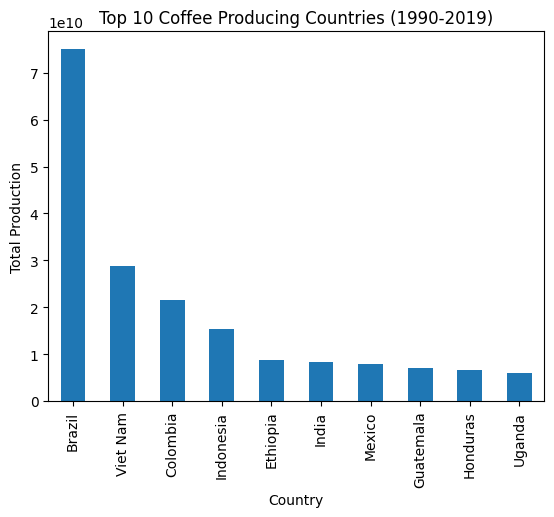

In [61]:
import matplotlib.pyplot as plt

top_producers.plot(kind="bar")

plt.title("Top 10 Coffee Producing Countries (1990-2019)")
plt.ylabel("Total Production")
plt.show()

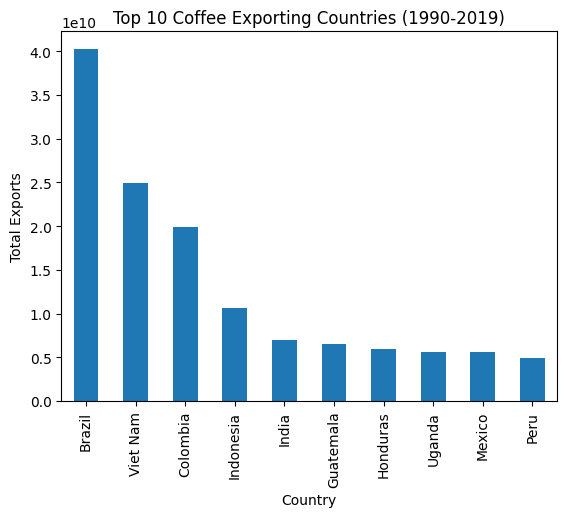

In [62]:
top_exporters.plot(kind="bar")

plt.title("Top 10 Coffee Exporting Countries (1990-2019)")
plt.ylabel("Total Exports")
plt.show()

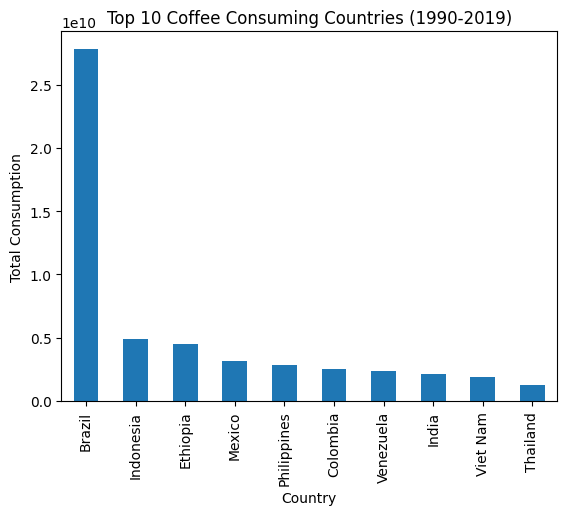

In [63]:
top_consumers.plot(kind="bar")

plt.title("Top 10 Coffee Consuming Countries (1990-2019)")
plt.ylabel("Total Consumption")
plt.show()

   Brazil is not only the world's largest coffee producer and exporter, but also its largest domestic consumer, making it a uniquely dominant actor across the entire coffee value chain.         

In [64]:
production_share = (
    top_producers /
    top_producers.sum()
) * 100

production_share

Country
Brazil       40.531135
Viet Nam     15.548472
Colombia     11.659321
Indonesia     8.315830
Ethiopia      4.679962
India         4.438501
Mexico        4.239471
Guatemala     3.789813
Honduras      3.602054
Uganda        3.195441
Name: Production, dtype: float64

In [65]:
export_share = (
    top_exporters /
    top_exporters.sum()
) * 100

In [66]:
consumption_share = (
    top_consumers /
    top_consumers.sum()
) * 100

## Key Findings

Finding 1

Brazil dominates the global coffee industry, leading production, exports and domestic consumption throughout the period 1990–2019.

Finding 2

Coffee production is highly concentrated among a small group of countries, with Brazil, Vietnam and Colombia accounting for a substantial share of global output.

Finding 3

Some producing countries such as Vietnam and Uganda appear significantly more export-oriented than countries with larger domestic markets.

Finding 4

Domestic consumption patterns differ considerably across producing countries, suggesting distinct market structures and consumption cultures.

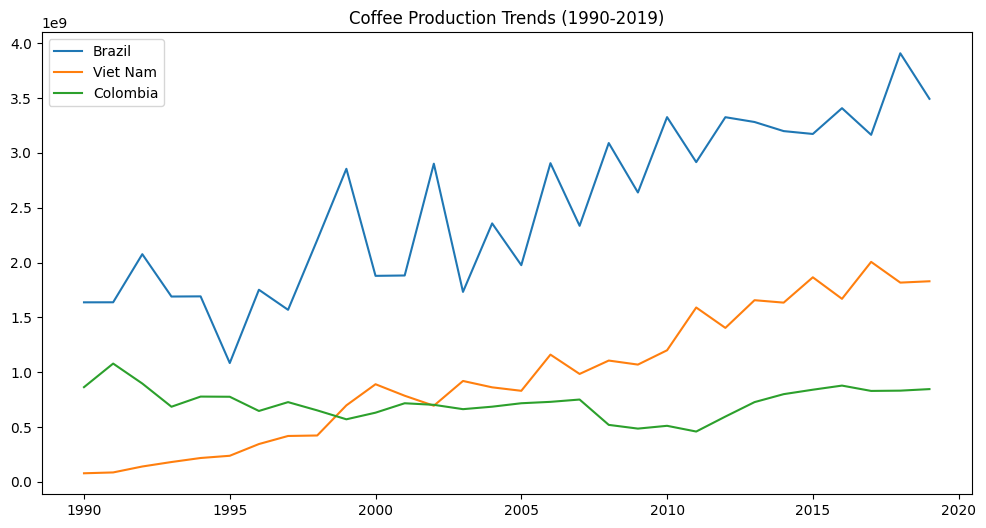

In [67]:
top_3 = ["Brazil", "Viet Nam", "Colombia"]

production_trends = (
    producer_countries[
        producer_countries["Country"].isin(top_3)
    ]
)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for country in top_3:
    data = production_trends[
        production_trends["Country"] == country
    ]
    plt.plot(
        data["Year"],
        data["Production"],
        label=country
    )

plt.title("Coffee Production Trends (1990-2019)")
plt.legend()
plt.show()

Vietnam experienced the most significant production growth among major coffee-producing countries between 1990 and 2019, transforming from a secondary producer into a global coffee powerhouse.